In [2]:
# all imports 
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
import nltk
from wordcloud import WordCloud

### looking at data

In [3]:
df = pd.read_csv('/Users/Diane/Desktop/PSYCH 186B/project/reviews_imdb_parasite_new.csv')
df

,id,author,date,user_rating,review_title,review_text
0,review_1,mysticfall,NaN,10.0,For those who didn't like the movie because of...,10/10For those who didn't like the movie becau...
1,review_2,Jeremy_Urquhart,NaN,10.0,One of the best films of this decade,I am remarkably stingy with my 10/10 ratings. ...
2,review_3,jtindahouse,NaN,8.0,"You name a genre, this movie covers it",I can't remember the last time I saw a movie t...
3,review_4,nehpetstephen,NaN,10.0,Meritocracy: it's metaphorical,"In a meritocracy, success and fortune are rese..."
4,review_5,keezo9uno,NaN,10.0,A true masterpiece.,This movie is a gosh darn masterpiece. It will...
5,review_6,impeyrules-54634,NaN,9.0,An original dark comedy about class struggles,This is a well written and well perfomed origi...
6,review_7,0U,NaN,10.0,Great,The most original film of 2019 and it is wicke...
7,review_8,southbankcinema,NaN,NaN,Society can only be as strong as its most vuln...,Society can only be as strong as its most vuln...
8,review_9,sandeepventrapragada98,NaN,10.0,A brilliant piece of art which will slowly gro...,Well written and performed also technically sh...
9,review_10,DJKwa,NaN,9.0,Achieves what Jordan Peele set out to do with Us,"As a film about a family imposing on another, ..."


need to think about how to turn this into a function!!

In [4]:
# do i need this code every time 
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# preprocessing the data 
lex = pd.read_csv("/Users/Diane/Desktop/PSYCH 186B/project/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt", sep='\t', names=['word', 'emotion', 'assoc'])
lex = lex[lex['assoc'] == 1]

emotion_map = lex.groupby('word')['emotion'].apply(list).to_dict()
print("Review dataset columns:", df.columns)

Review dataset columns: Index(['id', 'author', 'date', 'user_rating', 'review_title', 'review_text'], dtype='object')


[nltk_data] Downloading package stopwords to /Users/Diane/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
df.columns

Index(['id', 'author', 'date', 'user_rating', 'review_title', 'review_text'], dtype='object')

In [6]:
# define necessary functions 

def simple_tokenizer(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|[^a-z\s]", "", text)
    return [word for word in text.split() if word not in stop_words]

def get_emotions(text):
    words = simple_tokenizer(text)
    emotions = [emo for word in words for emo in emotion_map.get(word, [])]
    return Counter(emotions)

def normalize(counter):
    total = sum(counter.values())
    return {emotion: count / total for emotion, count in counter.items()} if total > 0 else {}

# apply functions 
df['emotion_counts'] = df['review_text'].apply(get_emotions)
df['emotion_normalized'] = df['emotion_counts'].apply(normalize)

# split into columns 
emotion_df = df['emotion_normalized'].apply(pd.Series).fillna(0)
df = pd.concat([df, emotion_df], axis=1)

# average by group 
type_col = 'review_type'
emotion_cols = lex['emotion'].unique().tolist()
grouped = df.groupby(type_col)[emotion_cols].mean()

# average counts plot
grouped.plot(kind='bar', figsize=(12, 6))
plt.title("Average Emotion Scores by Review Type")
plt.ylabel("Normalized Emotion Frequency")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()


KeyError: 'review_type'

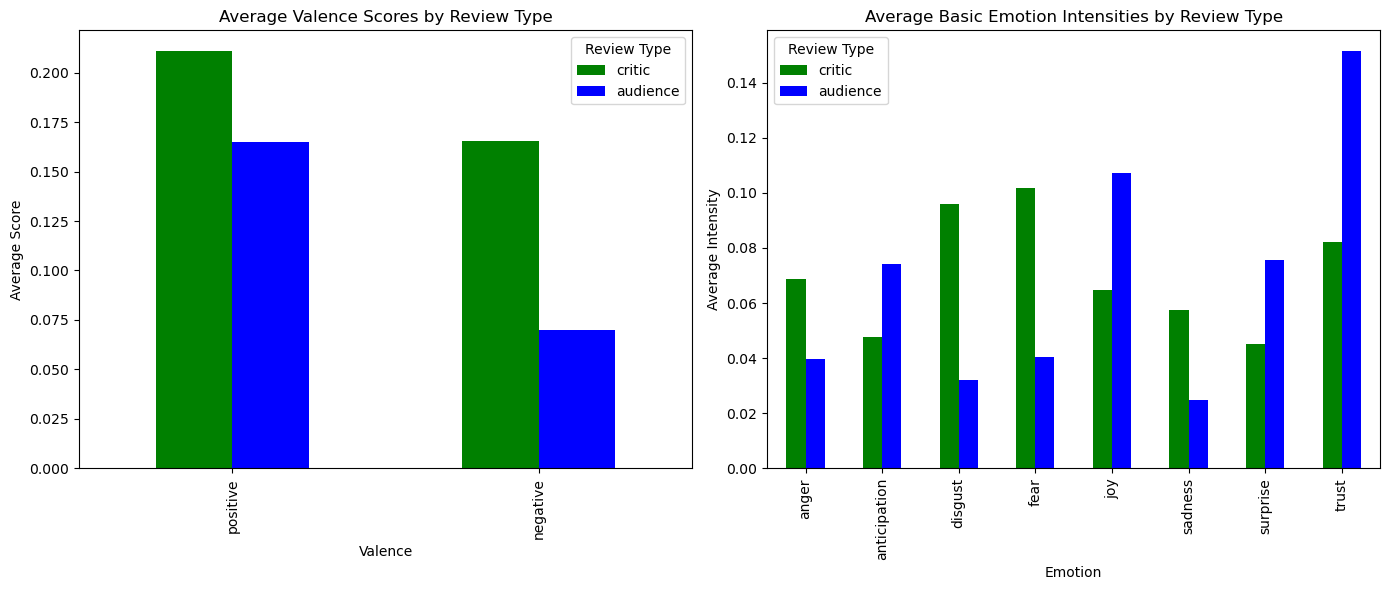

In [6]:
valence_emotions = ['positive', 'negative']
basic_emotions = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'trust']

for emotion in valence_emotions + basic_emotions:
    if emotion not in df.columns:
        df[emotion] = 0.0

types = ['critic', 'audience'] 

# mean calculations 
valence_means = df.groupby('review_type')[valence_emotions].mean().loc[types]
emotion_means = df.groupby('review_type')[basic_emotions].mean().loc[types]

# valence bar graph 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

valence_means.T.plot(kind='bar', ax=axes[0], color=['green', 'blue'])
axes[0].set_title('Average Valence Scores by Review Type')
axes[0].set_ylabel('Average Score')
axes[0].set_xlabel('Valence')
axes[0].legend(title='Review Type')

# emotions bar graph 
emotion_means.T.plot(kind='bar', ax=axes[1], color=['green', 'blue'])
axes[1].set_title('Average Basic Emotion Intensities by Review Type')
axes[1].set_ylabel('Average Intensity')
axes[1].set_xlabel('Emotion')
axes[1].legend(title='Review Type')

plt.tight_layout()
plt.show()

### word cloud 

In [ ]:
# need to fix 

all_tokens = []
for t in df[tweet_col].dropna().astype(str):
    all_tokens.extend(simple_tokenizer(t))

freq_counter = Counter(all_tokens)

top_n = 20 
most_common_words = set([w for w, count in freq_counter.most_common(top_n)])
print(f"Top {top_n} most common words being excluded:", most_common_words)

for party in df[party_col].unique():
    party_texts = df[df[party_col] == party][tweet_col].dropna().astype(str)
    tokens = []
    for t in party_texts:
        tokens.extend(simple_tokenizer(t))
    
    filtered_tokens = [w for w in tokens if w not in most_common_words]
    filtered_text = ' '.join(filtered_tokens)
    
    if filtered_text.strip():
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(filtered_text)
        
        plt.figure(figsize=(15, 7))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f"Most Frequent Words (Topics) for {party} (excluding top {top_n} global words)")
        plt.show()
    else:
        print(f"No text data for party: {party}")

notes: 
* labeling criteria: profitable (1): gross / budget >= 3.0, not profitable (0): gross / budget <  3.0

In [12]:
df.columns

Index(['movie_title', 'tomatometer', 'popcornmeter', 'review_type', 'reviewer',
       'publication', 'score', 'date', 'review_text'],
      dtype='object')

In [ ]:
import re
import numpy as np
import pandas as pd
from typing import Optional

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# functions

def assign_label(row: pd.Series):
    budget = row.get("budget", np.nan) # need to somehow pass in budget and gross 
    gross  = row.get("gross",  np.nan)

    if pd.notna(budget) and budget > 0 and pd.notna(gross):
        return 1 if (gross / budget) >= 3.0 else 0
    
    return np.nan   # will be dropped

def label_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # keep the rows w/ no valid target here bc keeping them would cause a crash when pytorch tries to load NaN into a tensor
    df["label"] = df.apply(assign_label, axis=1)
    df = df.dropna(subset=["label"])
    # int is needed so stratified split and value_counts rename works 
    df["label"] = df["label"].astype(int)
    return df


# 2. datapreprocessing 

# reminder to figure out if we're gonna get the separate scores 
NUMERIC_FEATURES = [
    "avg_critic_score",
    "avg_audience_score",
    "combined_score",
    "budget",
    "gross",
    "roi",
]

def preprocess(df: pd.DataFrame) -> pd.DataFrame:

    df = df.copy()

    # normalize score columns to 0-10, coerce turns non numeric strings into NaN 
    for col in ("avg_critic_score", "avg_audience_score", "combined_score", "score"):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Aggregate reviews per movie 
    # collapse mrows so model sees 1 row / movie, reviews joined w/ SEP so BERT can distinguish 
    # do we need this tho
    agg: dict = {"review_text": lambda x: " [SEP] ".join(x.dropna().astype(str))}

    # for numeric site-level columns, average across all rows for that movie
    for col in ("avg_critic_score", "avg_audience_score", "combined_score",
                "budget", "gross"):
        if col in df.columns:
            agg[col] = "mean"

    # function to derive critic and audience scores using review type -> may need to fix this if incomplete data 
    if "score" in df.columns and "review_type" in df.columns:
        def split_scores(g):
            # filter rows by review_type to compute separate averages
            # .mean() on an empty slice returns NaN which is handled downstream
            critics  = g.loc[g["review_type"].str.lower() == "critic",  "score"].mean()
            audience = g.loc[g["review_type"].str.lower() == "audience", "score"].mean()
            combined = g["score"].mean()   # overall average regardless of type
            return pd.Series({
                "avg_critic_score":   critics,
                "avg_audience_score": audience,
                "combined_score":     combined,
            })
        score_agg = df.groupby("movie_title").apply(split_scores).reset_index()
        agg.pop("score", None)   # remove raw score so it isn't double-counted
        movie_df = df.groupby("movie_title").agg(agg).reset_index()
        movie_df = movie_df.merge(score_agg, on="movie_title", how="left")
    else:
        movie_df = df.groupby("movie_title").agg(agg).reset_index()

    # roi feature
    # compute the feature so model doesn't have to to learn the division relationship itself 
    movie_df["roi"] = np.where(
        (movie_df["budget"] > 0) & movie_df["budget"].notna() & movie_df["gross"].notna(),
        movie_df["gross"] / movie_df["budget"],
        np.nan,
    )

    movie_df = label_dataset(movie_df)

    return movie_df


def build_numeric_matrix(movie_df: pd.DataFrame, scaler: Optional[StandardScaler] = None):
    """Return scaled numeric array + fitted scaler."""
    # only keep columns that actually exist in this dataset -> do we want this 
    cols = [c for c in NUMERIC_FEATURES if c in movie_df.columns]
    X_num = movie_df[cols].fillna(0).values.astype(np.float32)
    if scaler is None:
        # fit scaler training data only, then transform
        scaler = StandardScaler()
        X_num = scaler.fit_transform(X_num)
    else:
        # reuse the scaler fitted on training data
        X_num = scaler.transform(X_num)
    return X_num, scaler, cols


# dataset
class MovieDataset(Dataset):
    def __init__(self, texts, numeric_features, labels, tokenizer, max_len=256):
        self.texts    = texts
        self.numeric  = torch.tensor(numeric_features, dtype=torch.float32)
        self.labels   = torch.tensor(labels, dtype=torch.float32)
        self.tok      = tokenizer
        self.max_len  = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # tokenize 
        enc = self.tok(
            self.texts[idx],
            max_length=self.max_len, # cap token count 
            truncation=True, # drop excess tokens 
            padding="max_length", #pad shorter sequences to all have same shape 
            return_tensors="pt",
        )
        return {
            # squeeze(0) removes the batch dimension the tokeniser adds
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "numeric":        self.numeric[idx],
            "label":          self.labels[idx],
        }

https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html 

https://skimai.com/fine-tuning-bert-for-sentiment-analysis/ 

https://huggingface.co/docs/transformers/training 

https://huggingface.co/docs/transformers/en/model_doc/bert

In [ ]:
# model

# architecture overview: text input -> BERT -> token + fusion MLP -> 1 logit + numeric input -> small MLP -> 64-d vector 

class MovieClassifier(nn.Module):
    def __init__(self, num_dim: int, hidden_dim: int = 256, dropout: float = 0.3):
        super().__init__()

        self.bert = BertModel.from_pretrained("bert-base-uncased")

        # freeze all BERT parameters then selectively unfreeze top 2 transformer encoder blocks because [insert]
        # lower layers cpature general lang features that don't need training while upper are more task specific 
        # freeze BERT to reduce training time 

        for name, param in self.bert.named_parameters():
            if not any(f"encoder.layer.{i}" in name for i in [10, 11]):
                param.requires_grad = False

        bert_dim = self.bert.config.hidden_size  # 768 for bert-base -> how did we get this number

        # numeric MLP branch 
        # just 2 layers to compresss numeric feature into 64-dim bc 768 is way too much 
        # ReLU for learning nonlinearity 
        # dropout for regularizing randomly zeroing activations that reduce overfitting 
    
        self.numeric_branch = nn.Sequential(
            nn.Linear(num_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
        )

        # fusion MLP branch 
        # concatenate the 768-d BERT [CLS] embedding and the 64-d numeric embedding into a single 832-d vector, then pass through a deep MLP.
        fusion_in = bert_dim + 64   # 768 + 64 = 832
        self.fusion = nn.Sequential(
            nn.Linear(fusion_in, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),

            # only need single output neuron bc produces one raw logit (no activation here)
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, input_ids, attention_mask, numeric):

        # run text through bert, grab CLS summary token
        bert_out  = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_features = bert_out.last_hidden_state[:, 0, :] # [B, 768]

        # run numeric features through small MLP 
        num_features = self.numeric_branch(numeric)           # [B, 64]

        # combine botht features sets side by side 
        combined = torch.cat([text_features, num_features], dim=1)   # [B, 832]
        
        # final 
        output = self.fusion(combined) # [B, 1]
        return output.squeeze(1) # remove unnecssary dimension 

In [ ]:
# training 

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()   # activates dropout and batch norm (if any) during training
    
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attn_mask = batch["attention_mask"].to(device)
        numeric   = batch["numeric"].to(device)
        labels    = batch["label"].to(device)   # float32 for BCEWithLogitsLoss

        # Zero gradients before each backward pass — PyTorch accumulates gradients by default, so we must clear them each step
        optimizer.zero_grad()
        logits = model(input_ids, attn_mask, numeric)   # raw logits, shape [B]
        loss   = criterion(logits, labels)              # BCE loss (sigmoid applied internally)
        loss.backward()                                 # compute gradients
        
        # Clip gradients to max norm of 1.0 to prevent exploding gradients which are common when fine-tuning large pretrained models like BERT
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()   # update weights

        # Apply sigmoid to convert logits to probabilities, then threshold at 0.5 to get binary predictions. This is separate from the loss (which handles sigmoid internally) and is only used for tracking accuracy.
        preds = (torch.sigmoid(logits) >= 0.5).float()
        total_loss += loss.item() * labels.size(0)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()   # disables gradient tracking to save memory and speed up inference
def evaluate(model, loader, criterion, device):
    model.eval()   # disables dropout so predictions are deterministic
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attn_mask = batch["attention_mask"].to(device)
        numeric   = batch["numeric"].to(device)
        labels    = batch["label"].to(device)   # float32

        logits = model(input_ids, attn_mask, numeric)
        loss   = criterion(logits, labels)

        # Same sigmoid + threshold logic as train_epoch, but here we also
        # collect all predictions and labels to compute the full classification
        # report and confusion matrix after the loop.
        preds = (torch.sigmoid(logits) >= 0.5).float()
        total_loss += loss.item() * labels.size(0)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        # Cast to int before collecting so sklearn's classification_report
        # receives integer 0/1 values rather than floats.
        all_preds.extend(preds.cpu().int().tolist())
        all_labels.extend(labels.cpu().int().tolist())

    return total_loss / total, correct / total, all_preds, all_labels

In [ ]:
# main 

def main(
    csv_path: str,
    epochs: int = 5,
    batch_size: int = 16,
    lr: float = 2e-5,
    max_len: int = 256,
    dropout: float = 0.3,
    seed: int = 42,
):
    torch.manual_seed(seed)   # makes weight init and data shuffling reproducible
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # ── Load & preprocess ─────────────────────────────────────────────
    raw_df   = pd.read_csv(csv_path)
    movie_df = preprocess(raw_df)   # aggregate reviews, engineer ROI, assign labels

    print("\nLabel distribution:")
    # Check for class imbalance here — if one class dominates heavily you may
    # want to pass pos_weight to BCEWithLogitsLoss or oversample the minority class.
    print(movie_df["label"].value_counts().rename({0: "Not Profitable", 1: "Profitable"}))

    # ── Train/val/test split ──────────────────────────────────────────
    # stratify= ensures each split has the same class ratio as the full dataset,
    # which is important if classes are imbalanced.
    train_df, test_df = train_test_split(movie_df, test_size=0.15, random_state=seed,
                                         stratify=movie_df["label"])
    train_df, val_df  = train_test_split(train_df,  test_size=0.15, random_state=seed,
                                         stratify=train_df["label"])

    # Fit scaler on training data only, then apply to val and test.
    # Passing the fitted scaler to subsequent calls prevents data leakage.
    X_train, scaler, num_cols = build_numeric_matrix(train_df)
    X_val,  _,  _             = build_numeric_matrix(val_df,  scaler)
    X_test, _,  _             = build_numeric_matrix(test_df, scaler)
    print(f"\nNumeric features used: {num_cols}")

    # ── Tokenizer & Datasets ──────────────────────────────────────────
    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

    train_ds = MovieDataset(train_df["review_text"].tolist(), X_train,
                            train_df["label"].tolist(), tokenizer, max_len)
    val_ds   = MovieDataset(val_df["review_text"].tolist(),   X_val,
                            val_df["label"].tolist(),   tokenizer, max_len)
    test_ds  = MovieDataset(test_df["review_text"].tolist(),  X_test,
                            test_df["label"].tolist(),  tokenizer, max_len)

    # shuffle=True on train loader randomises batch order each epoch, which
    # helps the model generalise. Val and test loaders don't need shuffling.
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size)

    # ── Model, loss, optimiser ────────────────────────────────────────
    model     = MovieClassifier(num_dim=X_train.shape[1], dropout=dropout).to(device)
    # BCEWithLogitsLoss combines sigmoid + binary cross-entropy in one numerically
    # stable operation. It expects raw logits (not sigmoid-activated outputs).
    criterion = nn.BCEWithLogitsLoss()
    # AdamW is Adam with decoupled weight decay — preferred over plain Adam for
    # transformer fine-tuning as it regularises weights without affecting gradients.
    # filter(...) ensures we only pass parameters that require gradients (unfrozen ones).
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    # Cosine annealing smoothly decays the learning rate from lr down to ~0 over
    # T_max epochs, helping the model converge without oscillating near the minimum.
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # ── Training ──────────────────────────────────────────────────────
    # Track the best validation accuracy and save that model state —
    # the final epoch is not necessarily the best due to overfitting.
    best_val_acc, best_state = 0.0, None
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        print(f"Epoch {epoch}/{epochs}  "
              f"train_loss={tr_loss:.4f} train_acc={tr_acc:.3f}  "
              f"val_loss={vl_loss:.4f} val_acc={vl_acc:.3f}")

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            # Clone weights to CPU so they're preserved even if training continues
            # and modifies the model in-place on GPU.
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # ── Test evaluation ───────────────────────────────────────────────
    # Restore best checkpoint before final evaluation on held-out test set.
    model.load_state_dict(best_state)
    model.to(device)
    _, test_acc, preds, labels = evaluate(model, test_loader, criterion, device)

    label_names = ["Not Profitable", "Profitable"]
    print(f"\nTest Accuracy: {test_acc:.3f}")
    print("\nClassification Report:")
    print(classification_report(labels, preds, target_names=label_names))
    print("Confusion Matrix:")
    print(confusion_matrix(labels, preds))

    # Save
    torch.save({"model_state": best_state, "scaler": scaler, "num_cols": num_cols},
               "movie_classifier.pt")
    print("\nModel saved to movie_classifier.pt")
    return model, scaler


# classify a new movie 

def predict_movie(
    model: MovieClassifier,
    scaler: StandardScaler,
    num_cols: list,
    review_texts: list[str],
    numeric_data: dict,
    tokenizer=None,
    device=None,
    max_len: int = 256,
) -> dict:
    """
    Predict a single movie at inference time.

    Parameters
    ----------
    review_texts : list of review strings for this movie
    numeric_data : dict with keys matching num_cols (missing → 0)
    """
    if tokenizer is None:
        tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Replicate the same aggregation done in preprocess() — join all reviews
    # for this movie with [SEP] so BERT sees them as a single input sequence.
    combined_text = " [SEP] ".join(review_texts)
    # Build numeric vector in the same column order the scaler was fitted on,
    # defaulting missing features to 0 (same as build_numeric_matrix's fillna).
    num_vec = np.array([[numeric_data.get(c, 0.0) for c in num_cols]], dtype=np.float32)
    # Apply the training scaler so the numeric values are on the same scale
    # the model saw during training. Never refit the scaler at inference time.
    num_vec = scaler.transform(num_vec)

    enc = tokenizer(combined_text, max_length=max_len, truncation=True,
                    padding="max_length", return_tensors="pt")
    model.eval()
    with torch.no_grad():   # no gradients needed at inference time
        logit = model(
            enc["input_ids"].to(device),
            enc["attention_mask"].to(device),
            torch.tensor(num_vec, dtype=torch.float32).to(device),
        )
    # Convert the single raw logit to a probability via sigmoid.
    # .item() extracts the scalar value from a 1-element tensor.
    prob_profitable = torch.sigmoid(logit).item()
    pred = 1 if prob_profitable >= 0.5 else 0
    return {
        "prediction": "Profitable" if pred == 1 else "Not Profitable",
        # Return both probabilities — they sum to 1 since this is binary.
        "probabilities": {
            "Profitable":     prob_profitable,
            "Not Profitable": 1 - prob_profitable,
        },
    }


# entry
if __name__ == "__main__":
    import sys
    csv_path = sys.argv[1] if len(sys.argv) > 1 else "movies.csv"
    main(csv_path)

# random stuff so i can close my tab

In [ ]:
# clustering 

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

# standardize emotion data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(emotion_df)

# labels 
y_true = df['Party'].astype('category').cat.codes
label_names = df['Party'].astype('category').cat.categories.tolist()

# define necessary functions for clustering
def find_best_k(X, k_range=range(2, 11)):
    best_k = 2
    best_score = -1
    best_labels = None
    for k in k_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
        labels = kmeans.fit_predict(X)
        score = silhouette_score(X, labels)
        print(f"K={k}, Silhouette Score={score:.3f}")
        if score > best_score:
            best_k = k
            best_score = score
            best_labels = labels
    print(f"\nBest K = {best_k} (Silhouette Score = {best_score:.3f})")
    return best_k, best_labels

def majority_vote_relabel_unique(y_true, y_pred):
    cluster_labels = np.unique(y_pred)
    assigned_labels = set()
    cluster_to_label = {}
    for cluster in cluster_labels:
        indices = np.where(y_pred == cluster)[0]
        true_in_cluster = y_true[indices]
        for label, _ in Counter(true_in_cluster).most_common():
            if label not in assigned_labels:
                cluster_to_label[cluster] = label
                assigned_labels.add(label)
                break
    new_pred = np.array([cluster_to_label.get(c, -1) for c in y_pred])
    return new_pred

def evaluate_clustering(y_true, y_pred, label_names, method_name):
    labels = list(range(len(label_names)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    print(f"\n {method_name} Evaluation")
    print("Confusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, labels=labels, target_names=label_names, zero_division=0))
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="g", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"{method_name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

# Run clustering and evaluate
best_k, emotion_labels = find_best_k(X_scaled)
aligned_emotion = majority_vote_relabel_unique(y_true, emotion_labels)
evaluate_clustering(y_true, aligned_emotion, label_names, "Emotion Profile Clustering")

In [ ]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import TfidfVectorizer

# tfidf vectorization
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
X = vectorizer.fit_transform(df["Tweet"])

# BERTopic
topic_model = BERTopic()
topics, _ = topic_model.fit_transform(df["Tweet"], X)
df["Topic"] = topics

# filter topics 
topic_counts = df["Topic"].value_counts()
top_topics = topic_counts.iloc[5:].nlargest(10).index
filtered_df = df[df["Topic"].isin(top_topics)]

# group by party 
grouped = filtered_df.groupby(["Party", "Topic"]).size().reset_index(name="Count")
grouped["Proportion"] = grouped.groupby("Party")["Count"].transform(lambda x: x / x.sum())

pivot = grouped.pivot(index="Topic", columns="Party", values="Proportion").fillna(0)

# label topics 
topic_labels = {
    topic: ", ".join([w for w, _ in topic_model.get_topic(topic)[:3]])
    for topic in pivot.index
}
pivot.rename(index=topic_labels, inplace=True)

pivot.plot(kind="bar", figsize=(14, 6), color=["blue", "red"])
plt.title("Top Topic Distribution by Party (TF-IDF)")
plt.ylabel("Proportion of Tweets")
plt.xlabel("Topic Keywords")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Party")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

valence_emotions = ['positive', 'negative']
for val in valence_emotions:
    if val not in df.columns:
        df[val] = 0.0

# filtering and sorting topics
df_filtered = df[df['Party'].isin(['Democrat', 'Republican']) & df['Topic'].isin(top_topics)].copy()

valence_by_topic_party = df_filtered.groupby(['Topic', 'Party'])[valence_emotions].mean().reset_index()

topics = sorted(top_topics)
fig, axes = plt.subplots(len(topics), 1, figsize=(10, 5*len(topics)), squeeze=False)

# plotting valence scores by topic and party
for i, topic in enumerate(topics):
    ax = axes[i, 0]
    data = valence_by_topic_party[valence_by_topic_party['Topic'] == topic]

    pos_dem = data[(data['Party'] == 'Democrat')]['positive'].values
    neg_dem = data[(data['Party'] == 'Democrat')]['negative'].values
    pos_rep = data[(data['Party'] == 'Republican')]['positive'].values
    neg_rep = data[(data['Party'] == 'Republican')]['negative'].values

    pos_dem = pos_dem[0] if len(pos_dem) > 0 else 0
    neg_dem = neg_dem[0] if len(neg_dem) > 0 else 0
    pos_rep = pos_rep[0] if len(pos_rep) > 0 else 0
    neg_rep = neg_rep[0] if len(neg_rep) > 0 else 0

    x = np.arange(len(valence_emotions))
    width = 0.35
    ax.bar(x - width/2, [pos_dem, neg_dem], width, label='Democrat', color='blue')
    ax.bar(x + width/2, [pos_rep, neg_rep], width, label='Republican', color='red')

    ax.set_xticks(x)
    ax.set_xticklabels(valence_emotions)
    ax.set_ylim(0, max([pos_dem, neg_dem, pos_rep, neg_rep]) * 1.2 + 0.01)

    label = topic_labels.get(topic, f"Topic {topic}")
    ax.set_title(f"Valence Scores for: {label}")
    ax.set_ylabel("Average Score")
    ax.legend()

plt.tight_layout()
plt.show()